In [1]:
import numpy as np
import itertools
from helper import effMap, electron_reco, muon_reco

# Cosmetics:
import matplotlib.pyplot as plt

import seaborn as sns
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']
cm_rev = plt.colormaps['RdYlBu_r']

In [2]:
pT_list = np.random.uniform(0.,1000.,300)
d0_list = np.random.uniform(0.,400.,300)
electron_effs_binned = []
electron_effs_smooth = []
for pT, d0 in itertools.product(pT_list, d0_list):
    eff = electron_reco.efficiency(method='binned',Lepton_p_textT_GeV=pT, Lepton_d_0_mm=d0)
    electron_effs_binned.append([pT,d0,eff])
    eff = electron_reco.efficiency(method='smooth',Lepton_p_textT_GeV=pT, Lepton_d_0_mm=d0)
    electron_effs_smooth.append([pT,d0,eff])

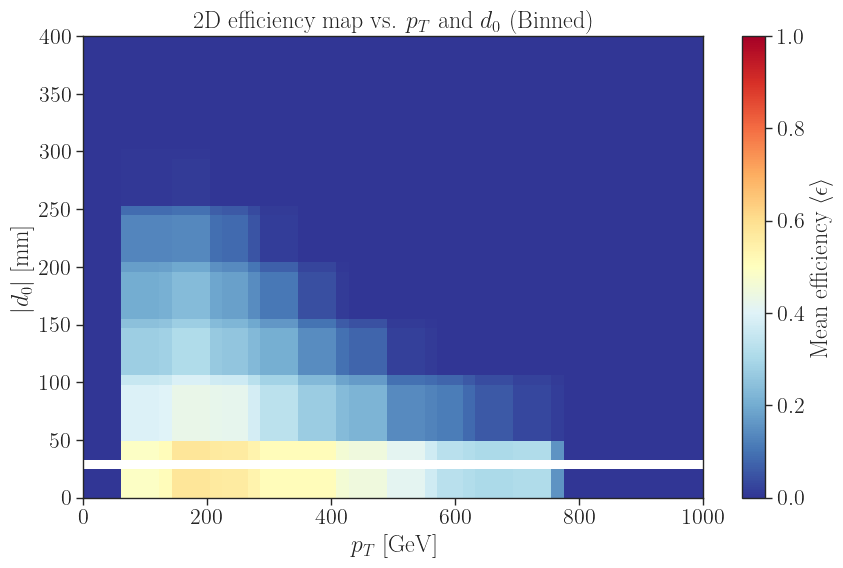

In [3]:
# 2D binned efficiency map: <efficiency> as a function of pT and d0
arr = np.asarray(electron_effs_binned, dtype=float)
if arr.size == 0:
    raise RuntimeError("electron_effs is empty. Run the data-building cell first.")

pT_vals = arr[:, 0]
d0_vals = arr[:, 1]
eff_vals = arr[:, 2]

# Choose binning for pT and d0 (adjust as needed)
xbins = np.linspace(0.0, 1000.0, 50)  # pT bins (GeV)
ybins = np.linspace(0.0, 400.0, 50)   # d0 bins (mm)

# Compute mean efficiency per 2D bin = sum(eff)/count
sum_eff, xedges, yedges = np.histogram2d(pT_vals, d0_vals, bins=[xbins, ybins], weights=eff_vals)
counts, _, _ = np.histogram2d(pT_vals, d0_vals, bins=[xbins, ybins])
mean_eff = np.divide(sum_eff, counts, out=np.full_like(sum_eff, np.nan), where=counts > 0)

fig, ax = plt.subplots(figsize=(9, 6))
mesh = ax.pcolormesh(xedges, yedges, mean_eff.T, shading='auto', cmap=cm_rev, vmin=0.0, vmax=1.0)

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label(r'Mean efficiency $\langle\epsilon\rangle$')

ax.set_xlabel(r'$p_T$ [GeV]')
ax.set_ylabel(r'$|d_0|$ [mm]')
ax.set_title(r'2D efficiency map vs. $p_T$ and $d_0$ (Binned)')

plt.tight_layout()
plt.show()

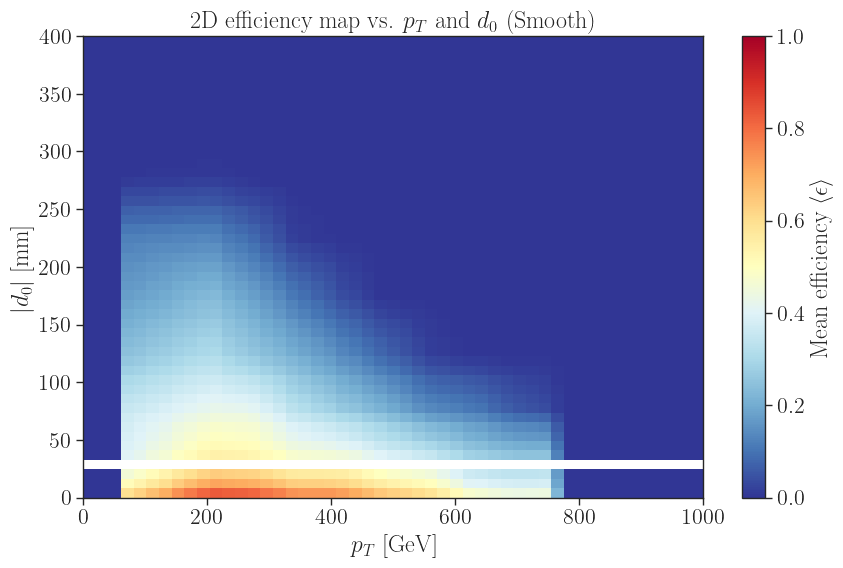

In [4]:
# 2D binned efficiency map: <efficiency> as a function of pT and d0
arr = np.asarray(electron_effs_smooth, dtype=float)
if arr.size == 0:
    raise RuntimeError("electron_effs is empty. Run the data-building cell first.")

pT_vals = arr[:, 0]
d0_vals = arr[:, 1]
eff_vals = arr[:, 2]

# Choose binning for pT and d0 (adjust as needed)
xbins = np.linspace(0.0, 1000.0, 50)  # pT bins (GeV)
ybins = np.linspace(0.0, 400.0, 50)   # d0 bins (mm)

# Compute mean efficiency per 2D bin = sum(eff)/count
sum_eff, xedges, yedges = np.histogram2d(pT_vals, d0_vals, bins=[xbins, ybins], weights=eff_vals)
counts, _, _ = np.histogram2d(pT_vals, d0_vals, bins=[xbins, ybins])
mean_eff = np.divide(sum_eff, counts, out=np.full_like(sum_eff, np.nan), where=counts > 0)

fig, ax = plt.subplots(figsize=(9, 6))
mesh = ax.pcolormesh(xedges, yedges, mean_eff.T, shading='auto', cmap=cm_rev, vmin=0.0, vmax=1.0)

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label(r'Mean efficiency $\langle\epsilon\rangle$')

ax.set_xlabel(r'$p_T$ [GeV]')
ax.set_ylabel(r'$|d_0|$ [mm]')
ax.set_title(r'2D efficiency map vs. $p_T$ and $d_0$ (Smooth)')

plt.tight_layout()
plt.show()

In [5]:
# # Evaluate on a dense grid for visualization
# x_plot = np.linspace(50.,800., 200)
# y_plot = np.linspace(0.,350., 200)
# XX, YY = np.meshgrid(x_plot, y_plot, indexing='ij')
# ZZ = np.zeros_like(XX)
# for i,j in np.ndindex(XX.shape):
#     x = XX[i,j]
#     y = YY[i,j]
#     ZZ[i,j] = electron_reco.efficiency(Lepton_p_textT_GeV=x, Lepton_d_0_mm=y)

# fig, ax = plt.subplots(figsize=(9, 6))
# im = ax.pcolormesh(x_plot, y_plot, ZZ.T, shading='auto', cmap=cm_rev, vmin=0.0, vmax=mean_eff.max())
# xmin,xmax = electron_reco.vars_limits['Lepton_p_textT_GeV']
# ymin,ymax = electron_reco.vars_limits['Lepton_d_0_mm']
# ax.vlines(x=xmin,ymin=ymin,ymax=ymax, color='red', linestyle='--')
# ax.vlines(x=xmax,ymin=ymin,ymax=ymax, color='red', linestyle='--')
# ax.hlines(y=ymin,xmin=xmin,xmax=xmax, color='red', linestyle='--')
# ax.hlines(y=ymax,xmin=xmin,xmax=xmax, color='red', linestyle='--')
# cbar = fig.colorbar(im, ax=ax)
# cbar.set_label(r'Interpolated efficiency')
# ax.set_xlabel(r'$p_T$ [GeV]')
# ax.set_ylabel(r'$|d_0|$ [mm]')
# ax.set_title(r'Smoothed interpolated efficiency $f(p_T, d_0)$')
# plt.tight_layout()
# plt.show()

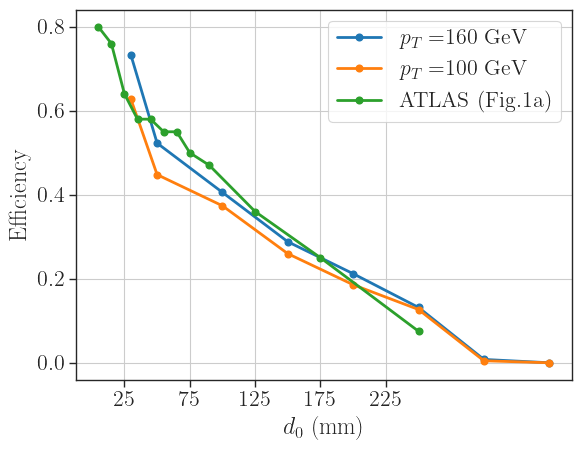

In [14]:
pTA = 160.
d0_list = np.array([5.0]+np.arange(25.,375.,50.).tolist())
effsA = [electron_reco.efficiency(method='smooth',Lepton_p_textT_GeV=pTA, Lepton_d_0_mm=d0) for d0 in d0_list]
pTB = 100.
effsB = [electron_reco.efficiency(method='smooth',Lepton_p_textT_GeV=pTB, Lepton_d_0_mm=d0) for d0 in d0_list]

effsAtlas = np.array([[250.,0.075],[175.,0.25],[125.,0.36],[90.,0.47],[75.,0.5],[65.,0.55],[55.,0.55],[45.,0.58],[35.,0.58],[25.,0.64],[15.,0.76],[5.,0.8]])
# effsAtlas.sort(axis=0)
plt.plot(d0_list+25.0,effsA,label=r'$p_T = $'+f'{pTA:1.0f} GeV',linewidth=2,marker='o')
plt.plot(d0_list+25.0,effsB,label=r'$p_T = $'+f'{pTB:1.0f} GeV',linewidth=2,marker='o')
plt.plot(effsAtlas[:,0],effsAtlas[:,1],label='ATLAS (Fig.1a)',linewidth=2,marker='o')

plt.xlabel(r'$d_0$ (mm)')
plt.ylabel('Efficiency')
plt.legend()
plt.xticks(np.arange(25.,275.,50.))
plt.grid()
plt.show()

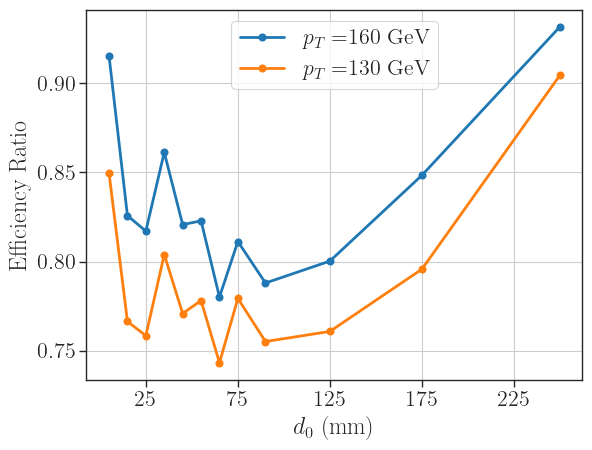

In [7]:
d0_list = effsAtlas[:,0]
effsA = np.array([electron_reco.efficiency(method='smooth',Lepton_p_textT_GeV=pTA, Lepton_d_0_mm=d0) for d0 in d0_list])
effsB = np.array([electron_reco.efficiency(method='smooth',Lepton_p_textT_GeV=pTB, Lepton_d_0_mm=d0) for d0 in d0_list])

# effsAtlas.sort(axis=0)
plt.plot(d0_list,effsA/effsAtlas[:,1],label=r'$p_T = $'+f'{pTA:1.0f} GeV',linewidth=2,marker='o')
plt.plot(d0_list,effsB/effsAtlas[:,1],label=r'$p_T = $'+f'{pTB:1.0f} GeV',linewidth=2,marker='o')

plt.xlabel(r'$d_0$ (mm)')
plt.ylabel('Efficiency Ratio')
plt.legend()
plt.xticks(np.arange(25.,275.,50.))
plt.grid()
plt.show()

In [8]:
electron_reco.efficiency(method='smooth',Lepton_p_textT_GeV=pTA, Lepton_d_0_mm=25.)

0.5229171428571429

In [9]:
electron_reco.efficiency(method='smooth',Lepton_p_textT_GeV=pTA, Lepton_d_0_mm=5.0)

0.7320840000000001

In [10]:
1.06*1.4

1.484

In [11]:
electron_reco._ycenters

AttributeError: 'effMap' object has no attribute '_ycenters'